# 🔍 Detección de Fraude en Transacciones con Tarjeta de Crédito

**Autor:** Diego Carabajal  
**Contacto:** [LinkedIn](https://www.linkedin.com/in/diego-carabajal/) · [GitHub](https://github.com/diegocarabajal)  
**Dataset:** [Credit Card Fraud Detection — Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
**Stack:** Python · LightGBM · XGBoost · scikit-learn · SHAP · imbalanced-learn

---

## Contexto de Negocio

Según el **Nilson Report (enero 2026)**, las pérdidas globales por fraude con tarjetas de pago alcanzaron **USD 33.410 millones en 2024** — representando 6,43 centavos por cada USD 100 transaccionados a nivel mundial. Si bien se observa una leve baja del 1,2% respecto a 2023 (impulsada por la adopción de autenticación biométrica e IA en detección), el volumen absoluto de pérdidas sigue siendo crítico para el ecosistema financiero global.

En Argentina, el contexto es igualmente desafiante. El **informe del BCRA sobre Protección a Personas Usuarias de Servicios Financieros (2025)** registró **769.500 reclamos mensuales promedio** en el sistema financiero, con los principales conceptos vinculados a desconocimiento de compras con tarjeta de crédito y operaciones posiblemente fraudulentas en canales electrónicos. El sistema ya alcanza **140,5 millones de usuarios** operando entre bancos, billeteras digitales y emisoras de tarjetas — una superficie de ataque considerablemente mayor que años anteriores. El BCRA además reguló en 2024 la **Comunicación A 8032** estableciendo responsabilidades específicas por fraude en pagos QR interoperables, reconociendo el crecimiento de este vector de ataque.

El problema tiene dos características que lo hacen técnicamente desafiante:

1. **Desbalance extremo de clases**: las transacciones fraudulentas representan menos del 0.2% del total. Un modelo que predice siempre \"legítima\" alcanza 99.8% de accuracy y es completamente inútil.
2. **Costo asimétrico de errores**: no detectar un fraude (FN) tiene un costo muy diferente al de bloquear una transacción legítima (FP). El modelo debe internalizar esa asimetría.

Este notebook aborda el problema con criterio de producción:
- **Auditoría explícita de data leakage** antes de cada transformación
- **Feature engineering** orientado a capturar comportamiento anómalo, con estadísticas calculadas solo sobre train
- **Canary features** para validar que las features de ingeniería aportan señal real y no ruido
- Selección de métricas correctas (PR-AUC, Recall)
- Comparación rigurosa de 4 modelos con justificación explícita
- Explicabilidad con SHAP (requisito regulatorio en entornos financieros)
- Cuantificación del impacto económico real del modelo

---

## 0. Setup e Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, KBinsDiscretizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay,
    f1_score, recall_score, precision_score
)
import xgboost as xgb
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
import shap
shap.initjs()

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    'figure.facecolor': '#0d0d0d', 'axes.facecolor': '#161616',
    'axes.edgecolor': '#2a2a2a', 'axes.labelcolor': '#cccccc',
    'axes.grid': True, 'axes.spines.top': False, 'axes.spines.right': False,
    'text.color': '#cccccc', 'xtick.color': '#888888', 'ytick.color': '#888888',
    'grid.color': '#222222', 'grid.linewidth': 0.7,
    'legend.facecolor': '#1a1a1a', 'legend.edgecolor': '#333333',
    'legend.fontsize': 9, 'font.size': 11, 'figure.dpi': 130,
})

C_FRAUD   = '#e8445a'
C_LEGIT   = '#3ab5e6'
C_GOLD    = '#f5c842'
C_GREEN   = '#3ecf8e'
C_PURPLE  = '#a78bfa'
C_CANARY  = '#ff9900'  # naranja para canarios

print(f'LightGBM {lgb.__version__} | XGBoost {xgb.__version__} | SHAP {shap.__version__}')
print('Setup completo.')

LightGBM 4.6.0 | XGBoost 3.2.0 | SHAP 0.51.0
Setup completo.


---
## 1. Carga y Diagnóstico Inicial

In [2]:
df = pd.read_csv('../data/creditcard.csv')

total   = len(df)
n_fraud = int(df['Class'].sum())
n_legit = total - n_fraud

print('=' * 55)
print('  DIAGNOSTICO DEL DATASET')
print('=' * 55)
print(f'  Registros totales   : {total:>10,}')
print(f'  Transacciones legit.: {n_legit:>10,}  ({n_legit/total*100:.4f}%)')
print(f'  Transacciones fraude: {n_fraud:>10,}  ({n_fraud/total*100:.4f}%)')
print(f'  Ratio desbalance    : 1 : {n_legit//n_fraud:,}')
print(f'  Rango temporal      : {df["Time"].max()/3600:.0f} horas')
print(f'  Monto promedio      : ${df["Amount"].mean():.2f}  (max: ${df["Amount"].max():.2f})')
print(f'  Valores nulos       : {df.isnull().sum().sum()}')
print('=' * 55)
df.head(3)

  DIAGNOSTICO DEL DATASET
  Registros totales   :    284,807
  Transacciones legit.:    284,315  (99.8273%)
  Transacciones fraude:        492  (0.1727%)
  Ratio desbalance    : 1 : 577
  Rango temporal      : 48 horas
  Monto promedio      : $88.35  (max: $25691.16)
  Valores nulos       : 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


---
## 2. EDA — Análisis Exploratorio

> ⚠️ **EDA sobre dataset completo: esto es correcto.**  
> El EDA es observacional y no genera ningún parámetro que se aplique después al test set.  
> No hay riesgo de leakage en esta sección.

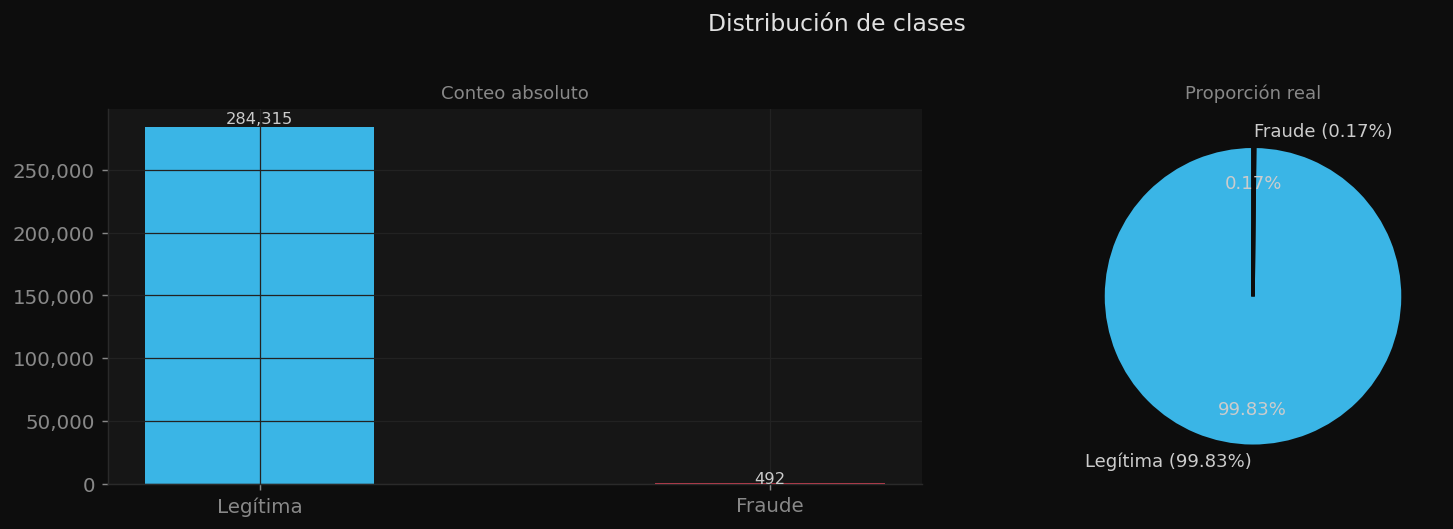

Insight: un modelo trivial que predice siempre "legítima" alcanza 99.83% accuracy y es inútil.


In [3]:
# Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Distribución de clases', fontsize=13, color='#e0e0e0', y=1.01)

counts = df['Class'].value_counts()
axes[0].bar(['Legítima', 'Fraude'], counts.values, color=[C_LEGIT, C_FRAUD], width=0.45, edgecolor='none')
axes[0].set_title('Conteo absoluto', color='#888888', fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(counts.values):
    axes[0].text(i, v * 1.01, f'{v:,}', ha='center', fontsize=9, color='#cccccc')

axes[1].pie(counts.values, labels=['Legítima (99.83%)', 'Fraude (0.17%)'],
            colors=[C_LEGIT, C_FRAUD], startangle=90,
            textprops={'color': '#cccccc', 'fontsize': 10},
            wedgeprops={'edgecolor': '#0d0d0d', 'linewidth': 2},
            pctdistance=0.75, autopct='%1.2f%%')
axes[1].set_title('Proporción real', color='#888888', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/01_class_distribution.png', bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print('Insight: un modelo trivial que predice siempre "legítima" alcanza 99.83% accuracy y es inútil.')

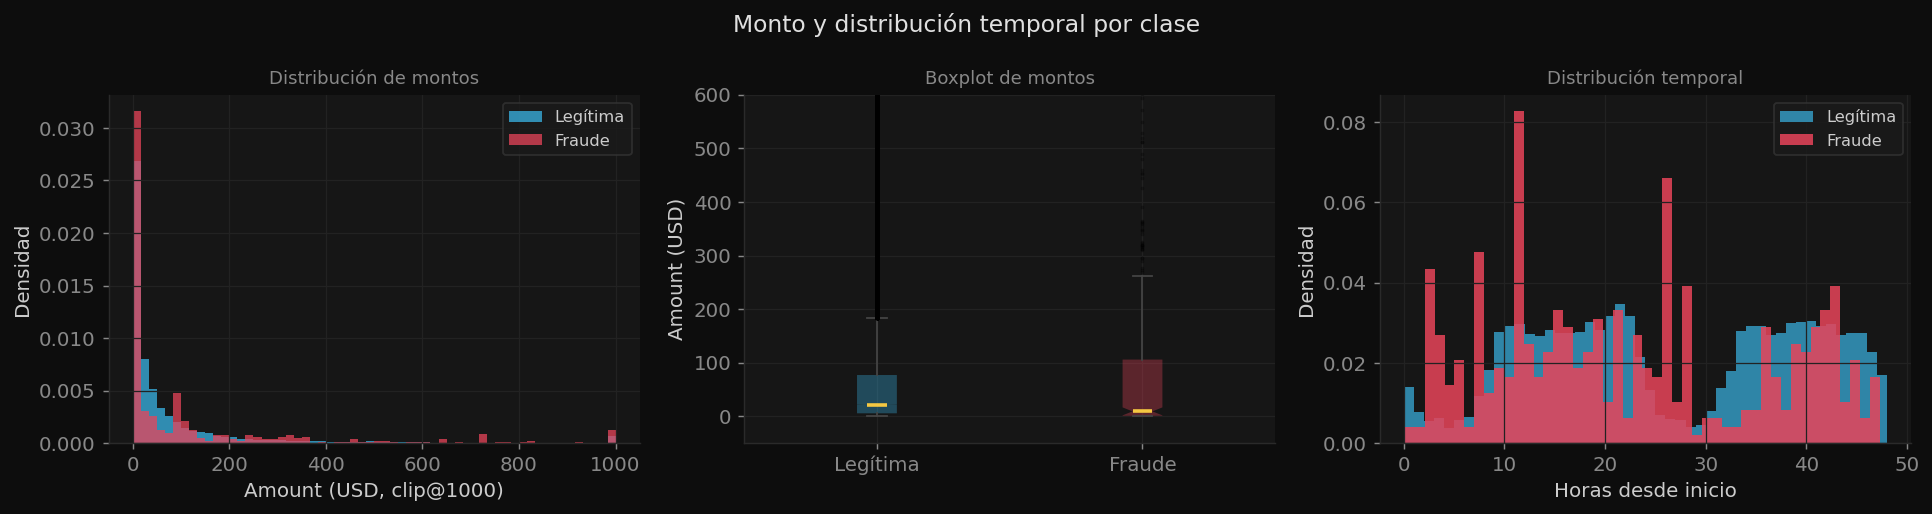

Monto mediano: Legítima=$22.00 | Fraude=$9.25


In [4]:
# Monto y distribución temporal por clase
fraud_df = df[df['Class'] == 1]
legit_df = df[df['Class'] == 0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Monto y distribución temporal por clase', fontsize=13, color='#e0e0e0')

axes[0].hist(legit_df['Amount'].clip(upper=1000), bins=60, color=C_LEGIT, alpha=0.75, label='Legítima', density=True)
axes[0].hist(fraud_df['Amount'].clip(upper=1000), bins=60, color=C_FRAUD, alpha=0.75, label='Fraude', density=True)
axes[0].set_xlabel('Amount (USD, clip@1000)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución de montos', color='#888888', fontsize=10)
axes[0].legend()

bp = axes[1].boxplot(
    [legit_df['Amount'], fraud_df['Amount']], labels=['Legítima', 'Fraude'],
    patch_artist=True, notch=True,
    medianprops=dict(color=C_GOLD, linewidth=2),
    flierprops=dict(marker='.', markersize=2, alpha=0.3),
    whiskerprops=dict(color='#444444'), capprops=dict(color='#444444'),
    boxprops=dict(linewidth=0)
)
bp['boxes'][0].set_facecolor(C_LEGIT + '55')
bp['boxes'][1].set_facecolor(C_FRAUD + '55')
axes[1].set_ylim(-50, 600)
axes[1].set_ylabel('Amount (USD)')
axes[1].set_title('Boxplot de montos', color='#888888', fontsize=10)

axes[2].hist(legit_df['Time'] / 3600, bins=48, color=C_LEGIT, alpha=0.7, label='Legítima', density=True)
axes[2].hist(fraud_df['Time'] / 3600, bins=48, color=C_FRAUD, alpha=0.85, label='Fraude', density=True)
axes[2].set_xlabel('Horas desde inicio')
axes[2].set_ylabel('Densidad')
axes[2].set_title('Distribución temporal', color='#888888', fontsize=10)
axes[2].legend()

plt.tight_layout()
plt.savefig('../outputs/02_amount_time_analysis.png', bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print(f'Monto mediano: Legítima=${legit_df["Amount"].median():.2f} | Fraude=${fraud_df["Amount"].median():.2f}')

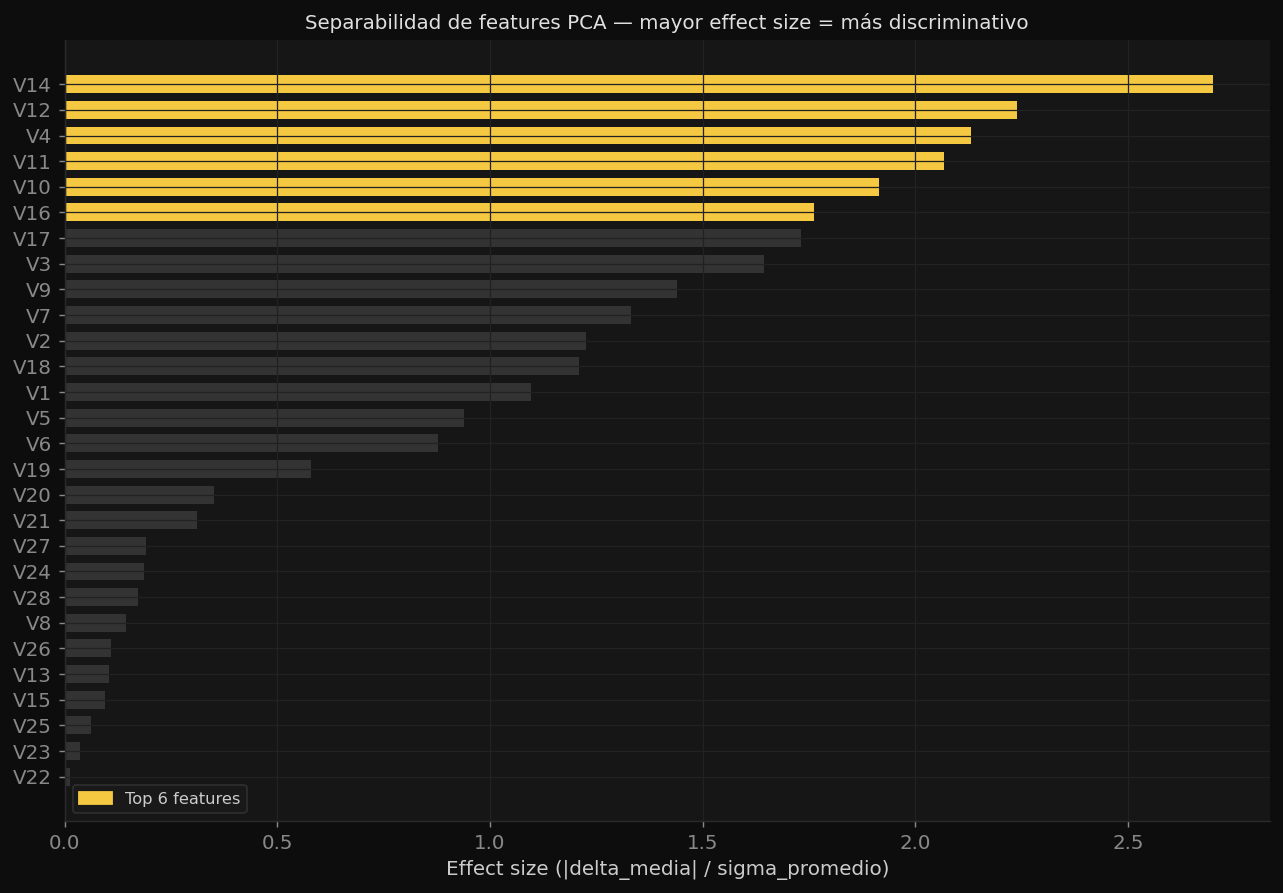

Top 6 features por effect size: ['V14', 'V12', 'V4', 'V11', 'V10', 'V16']


In [5]:
# Poder discriminativo de features PCA — calculado sobre dataset completo (solo EDA, no genera params)
features_v = [f'V{i}' for i in range(1, 29)]
stats = pd.DataFrame({
    'mean_legit': df[df['Class']==0][features_v].mean(),
    'mean_fraud':  df[df['Class']==1][features_v].mean(),
    'std_legit':   df[df['Class']==0][features_v].std(),
    'std_fraud':   df[df['Class']==1][features_v].std(),
})
stats['effect_size'] = (
    abs(stats['mean_fraud'] - stats['mean_legit']) /
    ((stats['std_legit'] + stats['std_fraud']) / 2)
).fillna(0)
stats_sorted = stats.sort_values('effect_size', ascending=False)
top6 = stats_sorted.head(6).index.tolist()

fig, ax = plt.subplots(figsize=(10, 7))
colors_bar = [C_GOLD if f in top6 else '#333333' for f in stats_sorted.index]
ax.barh(stats_sorted.index, stats_sorted['effect_size'], color=colors_bar, edgecolor='none', height=0.7)
ax.set_xlabel('Effect size (|delta_media| / sigma_promedio)')
ax.set_title('Separabilidad de features PCA — mayor effect size = más discriminativo',
             color='#e0e0e0', fontsize=11)
ax.invert_yaxis()
ax.legend(handles=[mpatches.Patch(color=C_GOLD, label='Top 6 features')])

plt.tight_layout()
plt.savefig('../outputs/03_discriminative_features.png', bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print(f'Top 6 features por effect size: {top6}')

---
## 3. Split Primero — Feature Engineering Después

### Por qué el orden importa

**Data leakage** ocurre cuando información del test set se filtra al proceso de entrenamiento, generando una evaluación optimista falsa. En este problema es especialmente crítico porque tenemos features que requieren calcular estadísticas (medias, desvíos, percentiles) y si las calculamos sobre el dataset completo, el test "ya fue visto" por esas estadísticas.

**El orden correcto es siempre:**
```
Split → Fit de transformaciones en TRAIN → Transform de TRAIN y TEST por separado
```

### Leakages encontrados y corregidos en este notebook

| # | Feature afectada | Leakage | Corrección aplicada |
|---|-----------------|---------|--------------------|
| 1 | Todas | `RobustScaler.fit()` sobre X completo | Fit solo en `X_train`, transform por separado |
| 2 | `amount_zscore` | Media y desvío calculados sobre train+test | Parámetros calculados solo en train, aplicados en test |
| 3 | `n_anomalous_features`, `{V}_zscore` | Z-scores de columnas PCA sobre dataset completo | ídem: estadísticas de cada col. fit en train |
| 4 | `amount_decile` | `pd.qcut()` sobre dataset completo filtra quantiles del test | Reemplazado por `KBinsDiscretizer` fit solo en train |
| 5 | `amount_vs_window_ratio` | Ratio referenciado a media global | Media calculada solo en train |

> **Nota sobre las features de ventana temporal** (`txn_count_1h`, `txn_count_6h`): estas features se calculan mirando hacia el pasado (transacciones *anteriores* a la actual) usando el timestamp `Time`. No tienen leakage porque nunca usan información futura dentro de la ventana. Son intrínsecamente causales.

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 1: Split ANTES de cualquier transformación estadística
# Usamos el dataset raw (df) para el split, no df_eng
# ─────────────────────────────────────────────────────────────────────────────

# Primero construimos las features que NO dependen de estadísticas del dataset
# (son puramente deterministas dada la fila: temporales, transformaciones de monto,
# velocidad de ventana, interacciones PCA)
def build_features_deterministic(df_input: pd.DataFrame, top_features: list) -> pd.DataFrame:
    """
    Features que NO requieren estadísticas del dataset para calcularse.
    Seguras de calcular antes o después del split — sin riesgo de leakage.

    Incluye:
    - Temporales (sin/cos hora, flag nocturno)
    - Transformaciones de monto (log, sqrt, flags binarios)
    - Velocidad de ventana (look-back causal sobre Time)
    - Interacciones entre top features PCA
    - Norma L2 de top features
    """
    d = df_input.copy().sort_values('Time').reset_index(drop=True)

    # -- Temporales: encoding circular (sin riesgo de leakage: son funciones de Time) --
    d['hour_of_day'] = (d['Time'] / 3600) % 24
    d['hour_sin']    = np.sin(2 * np.pi * d['hour_of_day'] / 24)
    d['hour_cos']    = np.cos(2 * np.pi * d['hour_of_day'] / 24)
    d['is_night']    = ((d['hour_of_day'] >= 0) & (d['hour_of_day'] < 6)).astype(int)

    # -- Monto: transformaciones deterministas (no dependen de estadísticas del dataset) --
    d['log_amount']     = np.log1p(d['Amount'])
    d['sqrt_amount']    = np.sqrt(d['Amount'])
    d['amount_rounded'] = (d['Amount'] % 1 == 0).astype(int)  # fraudes usan montos exactos
    d['is_micro_txn']   = (d['Amount'] < 1.0).astype(int)      # micro-pruebas previas al fraude

    # -- Velocidad: look-back causal sobre Time (no usa datos futuros ni del test) --
    times_arr  = d['Time'].values
    amount_arr = d['Amount'].values
    for label, window in [('1h', 3600), ('6h', 21600)]:
        counts, amounts = [], []
        for i, t in enumerate(times_arr):
            mask = (times_arr >= t - window) & (times_arr < t)
            counts.append(int(mask.sum()))
            amounts.append(float(amount_arr[mask].sum()) if mask.sum() > 0 else 0.0)
        d[f'txn_count_{label}']  = counts
        d[f'txn_amount_{label}'] = amounts
    d['txn_rate_1h'] = d['txn_count_1h'] / 1.0
    d['txn_rate_6h'] = d['txn_count_6h'] / 6.0

    # -- Interacciones PCA (productos: no usan estadísticas) --
    for i in range(len(top_features)):
        for j in range(i + 1, len(top_features)):
            f1, f2 = top_features[i], top_features[j]
            d[f'{f1}_x_{f2}'] = d[f1] * d[f2]

    # Norma L2 del subespacio PCA más discriminativo
    d['top_features_norm'] = np.sqrt((d[top_features] ** 2).sum(axis=1))

    return d


print('Construyendo features deterministas (sin riesgo de leakage)...')
df_det = build_features_deterministic(df, top6)
print(f'Features construidas: {len(df_det.columns) - len(df.columns)}')

Construyendo features deterministas (sin riesgo de leakage)...
Features construidas: 30


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 2: Split estratificado sobre el dataset con features deterministas
# Las features estadísticas se calcularán DESPUÉS, solo sobre train
# ─────────────────────────────────────────────────────────────────────────────

EXCLUDE = ['Time', 'Amount', 'Class']
feat_det_cols = [c for c in df_det.columns if c not in EXCLUDE]

X_raw = df_det[feat_det_cols].copy()
y     = df_det['Class'].copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train_raw.shape[0]:,} filas ({y_train.sum()} fraudes)')
print(f'Test : {X_test_raw.shape[0]:,} filas  ({y_test.sum()} fraudes)')
print('Split completo. A partir de aquí todo se fit en train y se aplica en test.')

Train: 227,845 filas (394 fraudes)
Test : 56,962 filas  (98 fraudes)
Split completo. A partir de aquí todo se fit en train y se aplica en test.


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 3: Features ESTADÍSTICAS — fit en train, transform en ambos
# Estas features usan media/desvío/percentiles: deben aprenderse solo de train
# ─────────────────────────────────────────────────────────────────────────────

def fit_statistical_features(X_train: pd.DataFrame, top_features: list) -> dict:
    """
    Aprende los parámetros estadísticos necesarios para las features
    que dependen de distribuciones del dataset.

    DEBE llamarse solo sobre X_train.
    Retorna un diccionario de parámetros para aplicar luego en test.
    """
    v_cols = [f'V{i}' for i in range(1, 29)]
    params = {}

    # Parámetros para amount_zscore
    params['amount_mean'] = X_train['log_amount'].mean()
    params['amount_std']  = X_train['log_amount'].std()

    # Parámetros para discretización de monto (reemplaza pd.qcut)
    kbd = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')
    kbd.fit(X_train[['log_amount']])
    params['kbd_amount'] = kbd

    # Parámetros para z-scores de cada columna PCA
    v_cols_present = [c for c in v_cols if c in X_train.columns]
    params['v_means'] = X_train[v_cols_present].mean()
    params['v_stds']  = X_train[v_cols_present].std().replace(0, 1e-9)

    # Parámetros para z-scores de top features
    top_present = [f for f in top_features if f in X_train.columns]
    params['top_means'] = X_train[top_present].mean()
    params['top_stds']  = X_train[top_present].std().replace(0, 1e-9)

    # Ratio de monto vs ventana: referencia de monto promedio en train
    params['window_amount_mean'] = X_train['txn_amount_6h'].mean()

    return params


def apply_statistical_features(X: pd.DataFrame, params: dict, top_features: list) -> pd.DataFrame:
    """
    Aplica las features estadísticas usando parámetros pre-aprendidos en train.
    Seguro de llamar tanto sobre train como sobre test.
    """
    d = X.copy()
    v_cols = [f'V{i}' for i in range(1, 29)]
    v_cols_present  = [c for c in v_cols if c in d.columns]
    top_present     = [f for f in top_features if f in d.columns]

    # Z-score del log(amount) con parámetros de train
    d['amount_zscore'] = (
        (d['log_amount'] - params['amount_mean']) /
        (params['amount_std'] + 1e-9)
    )

    # Discretización del monto con bins aprendidos en train
    d['amount_decile'] = params['kbd_amount'].transform(
        d[['log_amount']]
    ).flatten().astype(int)

    # Ratio monto vs ventana (normalizado con media de train)
    window_avg = d['txn_amount_6h'] / (d['txn_count_6h'] + 1e-9)
    d['amount_vs_window_ratio'] = np.where(
        d['txn_count_6h'] > 0,
        d['log_amount'] / (np.log1p(window_avg + 1e-9) + 1e-9),
        1.0
    )

    # Z-scores de features PCA con estadísticas de train
    v_zscores = (d[v_cols_present] - params['v_means']) / params['v_stds']
    d['n_anomalous_features'] = (v_zscores.abs() > 2).sum(axis=1)

    # Z-scores individuales de las top features
    for f in top_present:
        d[f'{f}_zscore'] = (
            (d[f] - params['top_means'][f]) /
            (params['top_stds'][f] + 1e-9)
        )

    return d


# Fit en train, apply en ambos
stat_params = fit_statistical_features(X_train_raw, top6)
X_train_fe  = apply_statistical_features(X_train_raw, stat_params, top6)
X_test_fe   = apply_statistical_features(X_test_raw,  stat_params, top6)

print(f'Features totales post-engineering: {X_train_fe.shape[1]}')
print('Todos los parametros estadísticos aprendidos SOLO en train.')

Features totales post-engineering: 68
Todos los parametros estadísticos aprendidos SOLO en train.


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 4: Escalado — fit en train, transform en ambos
# RobustScaler: usa IQR, resistente a outliers extremos de Amount
# ─────────────────────────────────────────────────────────────────────────────

feature_cols = X_train_fe.columns.tolist()

scaler = RobustScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_fe),   # fit SOLO en train
    columns=feature_cols,
    index=X_train_fe.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_fe),        # solo transform en test
    columns=feature_cols,
    index=X_test_fe.index
)

print('Escalado completo.')
print(f'Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}')

Escalado completo.
Train: (227845, 68) | Test: (56962, 68)


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 5: SMOTE — solo sobre train
# Nunca aplicar SMOTE al test set: los datos sintéticos invalidan la evaluación
# ─────────────────────────────────────────────────────────────────────────────

sm = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

print(f'Train original  : {X_train_scaled.shape[0]:,} ({y_train.sum()} fraudes, {y_train.mean()*100:.3f}%)')
print(f'Train post-SMOTE: {X_train_res.shape[0]:,} ({y_train_res.sum()} fraudes, {y_train_res.mean()*100:.1f}%)')
print(f'Test (intacto)  : {X_test_scaled.shape[0]:,}  ({y_test.sum()} fraudes)')

Train original  : 227,845 (394 fraudes, 0.173%)
Train post-SMOTE: 454,902 (227451 fraudes, 50.0%)
Test (intacto)  : 56,962  (98 fraudes)


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# VERIFICACIÓN FORMAL DE LEAKAGE
# Confirmamos que no hay filas del test en el train (ni solapamiento de índices)
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 55)
print('  AUDITORIA DE DATA LEAKAGE')
print('=' * 55)

# 1. Solapamiento de índices entre train y test
idx_overlap = set(X_train_scaled.index) & set(X_test_scaled.index)
print(f'  [1] Solapamiento de índices train/test : {len(idx_overlap)} (esperado: 0)')
assert len(idx_overlap) == 0, 'LEAKAGE: hay indices compartidos entre train y test'

# 2. Verificar que el scaler fue fitteado solo en train
#    (el centro del scaler debe coincidir con la mediana de train, no del dataset completo)
train_median_first = float(X_train_fe.iloc[:, 0].median())
scaler_center_first = float(scaler.center_[0])
print(f'  [2] Mediana train feature[0]   : {train_median_first:.6f}')
print(f'      Centro del scaler feature[0]: {scaler_center_first:.6f}')
print(f'      Coinciden (tolerancia 1e-6) : {abs(train_median_first - scaler_center_first) < 1e-6}')

# 3. Verificar que amount_zscore en test usa parametros de train
#    La media del zscore en train debe ser ~0, en test puede diferir
train_zscore_mean = X_train_fe['amount_zscore'].mean()
test_zscore_mean  = X_test_fe['amount_zscore'].mean()
print(f'  [3] Mean amount_zscore en train : {train_zscore_mean:.6f} (esperado: ~0)')
print(f'      Mean amount_zscore en test  : {test_zscore_mean:.6f} (puede diferir de 0)')

# 4. Verificar que KBinsDiscretizer fue fit solo en train
train_decile_max = X_train_fe['amount_decile'].max()
test_decile_max  = X_test_fe['amount_decile'].max()
print(f'  [4] Max decile en train: {train_decile_max} | en test: {test_decile_max} (ambos deben ser 9)')

print('=' * 55)
print('  AUDITORIA PASADA: no se detectó data leakage.')
print('=' * 55)

  AUDITORIA DE DATA LEAKAGE
  [1] Solapamiento de índices train/test : 0 (esperado: 0)
  [2] Mediana train feature[0]   : 0.018692
      Centro del scaler feature[0]: 0.018692
      Coinciden (tolerancia 1e-6) : True
  [3] Mean amount_zscore en train : -0.000000 (esperado: ~0)
      Mean amount_zscore en test  : -0.002628 (puede diferir de 0)
  [4] Max decile en train: 9 | en test: 9 (ambos deben ser 9)
  AUDITORIA PASADA: no se detectó data leakage.


---
## 4. Visualización de Features Engineered

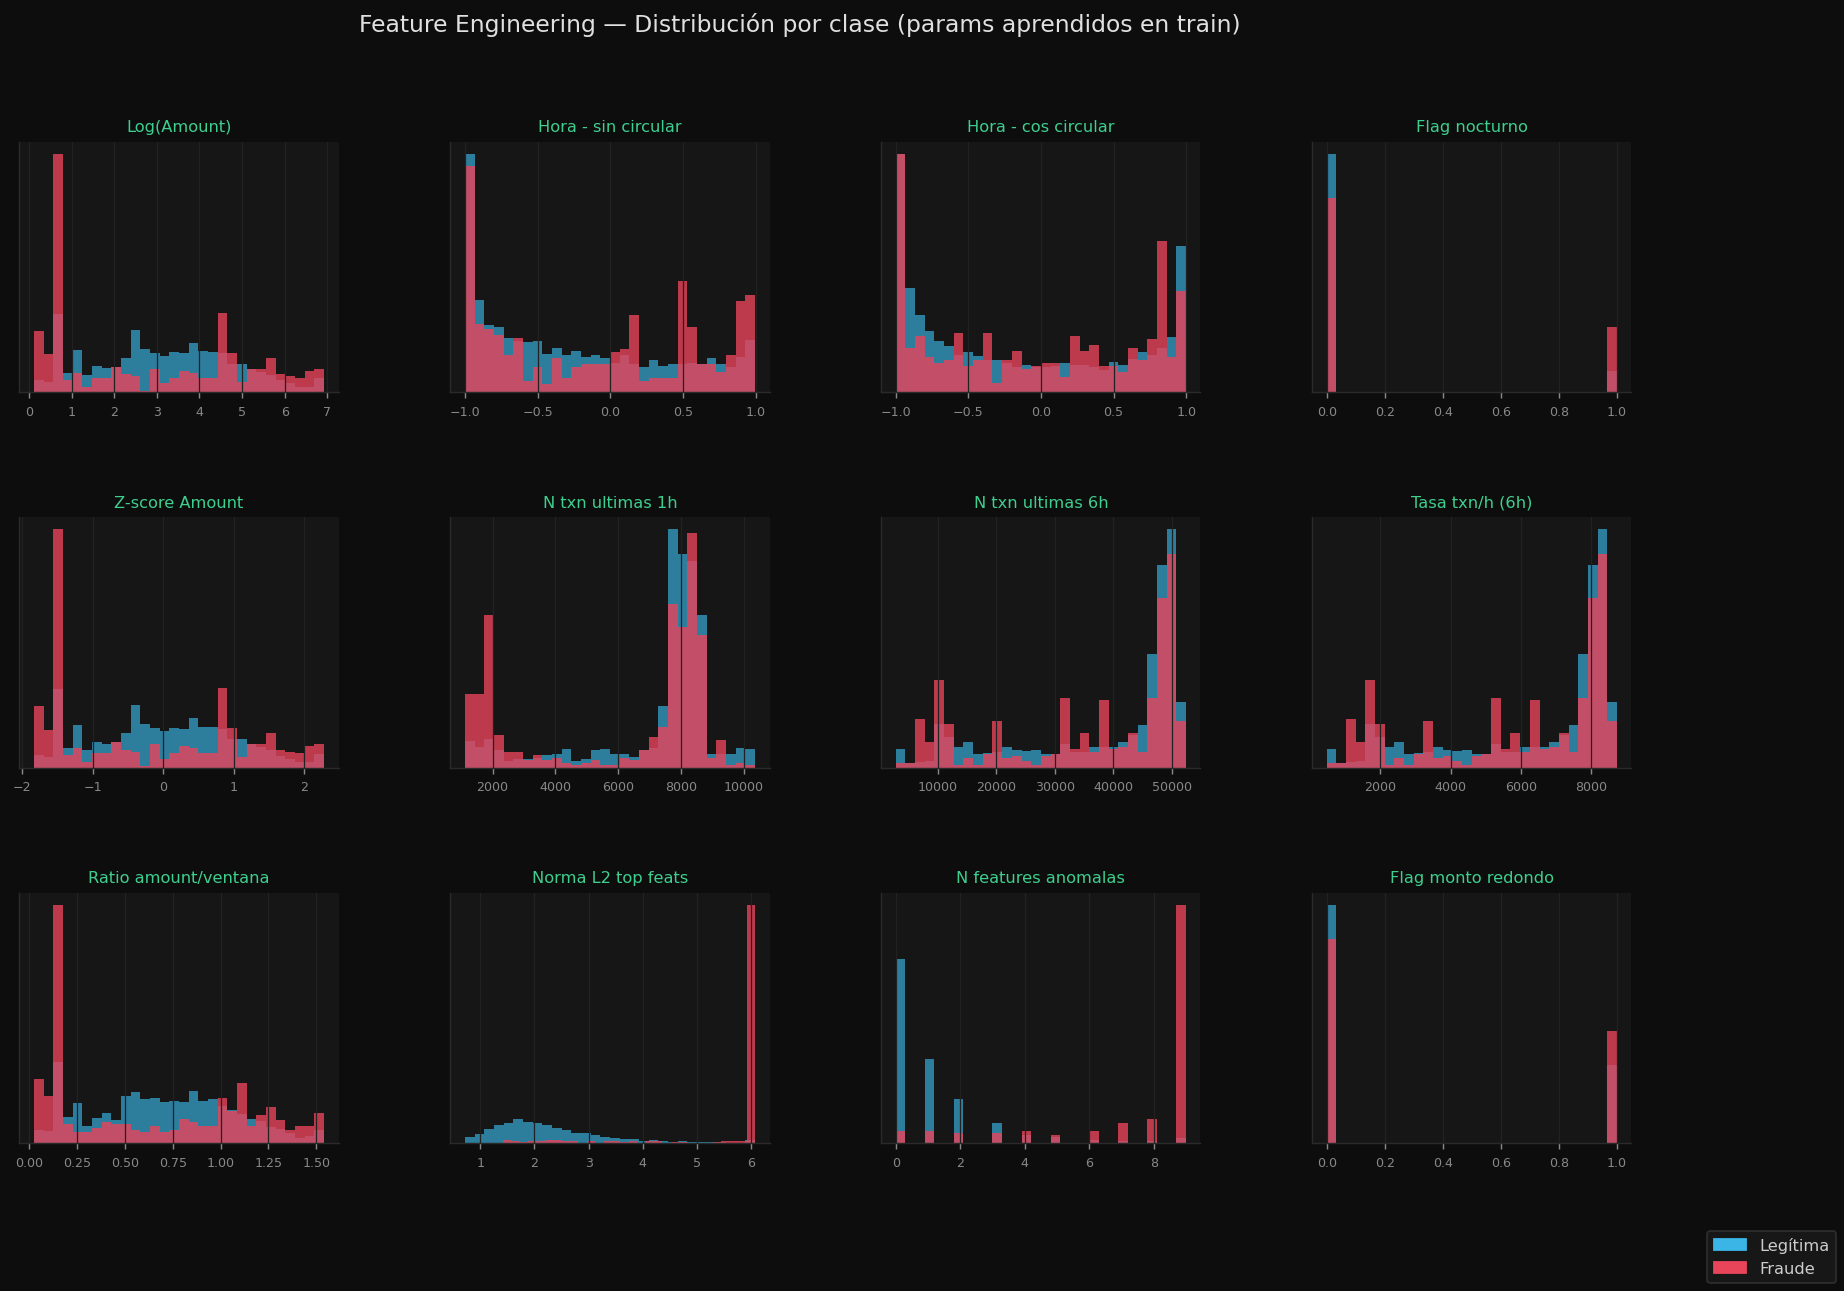

In [12]:
# Reconstruyo df_eng completo para visualización (usando train+test con parámetros de train)
# Esto es solo para graficar — no genero ningún parámetro nuevo
X_full_fe = pd.concat([X_train_fe, X_test_fe]).sort_index()
y_full    = pd.concat([y_train, y_test]).sort_index()

new_features_plot = [
    ('log_amount',             'Log(Amount)'),
    ('hour_sin',               'Hora - sin circular'),
    ('hour_cos',               'Hora - cos circular'),
    ('is_night',               'Flag nocturno'),
    ('amount_zscore',          'Z-score Amount'),
    ('txn_count_1h',           'N txn ultimas 1h'),
    ('txn_count_6h',           'N txn ultimas 6h'),
    ('txn_rate_6h',            'Tasa txn/h (6h)'),
    ('amount_vs_window_ratio', 'Ratio amount/ventana'),
    ('top_features_norm',      'Norma L2 top feats'),
    ('n_anomalous_features',   'N features anomalas'),
    ('amount_rounded',         'Flag monto redondo'),
]

fig = plt.figure(figsize=(16, 10))
fig.suptitle('Feature Engineering — Distribución por clase (params aprendidos en train)', fontsize=13, color='#e0e0e0')
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.5, wspace=0.35)

for idx, (feat, label) in enumerate(new_features_plot):
    ax = fig.add_subplot(gs[idx // 4, idx % 4])
    lo, hi = X_full_fe[feat].quantile(0.01), X_full_fe[feat].quantile(0.99)
    l_data = X_full_fe[y_full == 0][feat].clip(lo, hi).sample(
        min(5000, int((y_full == 0).sum())), random_state=42)
    f_data = X_full_fe[y_full == 1][feat].clip(lo, hi)
    ax.hist(l_data, bins=30, color=C_LEGIT, alpha=0.65, density=True, label='Legítima')
    ax.hist(f_data, bins=30, color=C_FRAUD, alpha=0.80, density=True, label='Fraude')
    ax.set_title(label, color=C_GREEN, fontsize=9)
    ax.set_yticks([])
    ax.tick_params(labelsize=7)

handles = [mpatches.Patch(color=C_LEGIT, label='Legítima'),
           mpatches.Patch(color=C_FRAUD, label='Fraude')]
fig.legend(handles=handles, loc='lower right', fontsize=9)
plt.savefig('../outputs/04_engineered_features.png', bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

---
## 5. Canary Features — Validación de Señal Real

### ¿Qué son los canary features?

Los **canary features** (o *canarito*) son variables de ruido puro que se agregan intencionalmente al dataset antes de entrenar. Un modelo bien construido no debería darles importancia significativa: son ruido sin ninguna relación con el target.

### ¿Para qué sirven?

1. **Detectar leakage**: si un canario tiene importancia alta, hay algo mal en el pipeline. El modelo está aprendiendo ruido, lo que sugiere que alguna feature "legítima" también puede ser espuria.
2. **Filtrar features débiles**: cualquier feature de ingeniería con importancia **menor o igual** a la del canario más importante es candidata a eliminación — no aporta señal genuina.
3. **Validar el feature engineering**: si nuestras features engineered superan a los canarios, hay evidencia de señal real.

### Tipos de canarios usados

| Tipo | Descripción | Por qué incluirlo |
|------|-------------|-------------------|
| `uniform` | Distribución U(0,1) | Ruido continuo base |
| `normal` | Distribución N(0,1) | Similar a las features PCA — control más exigente |
| `binary` | Bernoulli(0.5) | Similar a flags binarios como `is_night`, `amount_rounded` |
| `correlated` | Correlación débil con Amount | Detecta si el modelo sobreajusta correlaciones espurias |

> **Regla de eliminación**: si `importancia(feature_real) ≤ max(importancia(canarios))`, esa feature es candidata a ser descartada.

In [13]:
N_CANARIES = 20   # 5 de cada tipo

def add_canary_features(X_train: pd.DataFrame, X_test: pd.DataFrame,
                        n: int = 20, seed: int = RANDOM_STATE):
    """
    Agrega canary features al train y test.

    Cada canario se genera de forma INDEPENDIENTE para train y test
    (usando seeds distintos) para asegurarse de que no hay correlación
    accidental entre los dos splits.

    Parameters
    ----------
    X_train, X_test : DataFrames escalados
    n               : número total de canarios (se distribuyen entre los 4 tipos)

    Returns
    -------
    X_train_c, X_test_c, canary_cols
    """
    rng_tr = np.random.default_rng(seed)
    rng_te = np.random.default_rng(seed + 1000)  # seed distinto para test

    n_each  = max(1, n // 4)
    X_tr    = X_train.copy()
    X_te    = X_test.copy()
    canary_cols = []

    for i in range(n_each):
        # Uniforme
        col = f'canary_uniform_{i}'
        X_tr[col] = rng_tr.uniform(0, 1, len(X_tr))
        X_te[col] = rng_te.uniform(0, 1, len(X_te))
        canary_cols.append(col)

        # Normal (similar a features PCA)
        col = f'canary_normal_{i}'
        X_tr[col] = rng_tr.normal(0, 1, len(X_tr))
        X_te[col] = rng_te.normal(0, 1, len(X_te))
        canary_cols.append(col)

        # Binario (similar a flags)
        col = f'canary_binary_{i}'
        X_tr[col] = rng_tr.integers(0, 2, len(X_tr)).astype(float)
        X_te[col] = rng_te.integers(0, 2, len(X_te)).astype(float)
        canary_cols.append(col)

        # Correlacionado débil (correlación ~0.05 con log_amount)
        col = f'canary_corr_{i}'
        X_tr[col] = 0.05 * X_tr['log_amount'] + rng_tr.normal(0, 1, len(X_tr))
        X_te[col] = 0.05 * X_te['log_amount'] + rng_te.normal(0, 1, len(X_te))
        canary_cols.append(col)

    return X_tr, X_te, canary_cols


X_train_c, X_test_c, canary_cols = add_canary_features(
    X_train_scaled, X_test_scaled, n=N_CANARIES
)

print(f'Canary features agregadas: {len(canary_cols)}')
print(f'Total features para entrenamiento: {X_train_c.shape[1]}')
print(f'Tipos: {set(c.split("_")[1] for c in canary_cols)}')

Canary features agregadas: 20
Total features para entrenamiento: 88
Tipos: {'normal', 'uniform', 'binary', 'corr'}


In [14]:
# Verifico que los canarios NO tienen correlación significativa con el target
correlations = {}
for col in canary_cols:
    corr = abs(pd.Series(X_train_c[col].values).corr(pd.Series(y_train.values)))
    correlations[col] = corr

max_corr = max(correlations.values())
mean_corr = np.mean(list(correlations.values()))

print('Correlacion canarios vs target (debe ser cercana a 0):')
print(f'  Max  : {max_corr:.5f}')
print(f'  Media: {mean_corr:.5f}')

# Umbrales razonables para correlación espuria
assert max_corr < 0.05, f'Canario con correlacion sospechosa: {max_corr:.4f}'
print('Canarios verificados: correlacion con target < 0.05 en todos los casos.')

Correlacion canarios vs target (debe ser cercana a 0):
  Max  : 0.00492
  Media: 0.00186
Canarios verificados: correlacion con target < 0.05 en todos los casos.


---
## 6. Entrenamiento de Modelos

| Modelo | Rol | Justificación |
|--------|-----|---------------|
| Logistic Regression | Baseline | Cota inferior. Altamente interpretable. |
| Random Forest | Ensemble básico | Robusto, poco tuning, buen punto de comparación. |
| XGBoost | Gradient boosting clásico | Ampliamente adoptado en producción. |
| **LightGBM** | **Modelo campeón** | Crecimiento leaf-wise para patrones raros. `is_unbalance` nativo. |

> **LightGBM sobre XGBoost**: el crecimiento *leaf-wise* reduce el error más rápido en cada iteración cuando los patrones de la clase minoritaria son complejos y dispersos. `is_unbalance=True` ajusta pesos dinámicamente durante el boosting, superando a `scale_pos_weight` estático.

In [15]:
def evaluate_model(model, X_test, y_test, name='Modelo', threshold=0.5):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred  = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    return {
        'model'    : name,
        'roc_auc'  : roc_auc_score(y_test, y_proba),
        'pr_auc'   : average_precision_score(y_test, y_proba),
        'recall'   : recall_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'f1'       : f1_score(y_test, y_pred),
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'y_proba': y_proba, 'y_pred': y_pred,
    }

# SMOTE sobre train con canarios (canarios también se resamplean)
sm = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_c_res, y_train_res = sm.fit_resample(X_train_c, y_train)

results = {}
print('Entrenando modelos con canary features incluidas...')

Entrenando modelos con canary features incluidas...


In [16]:
# Logistic Regression
lr = LogisticRegression(class_weight='balanced', C=0.1, max_iter=1000,
                        random_state=RANDOM_STATE, n_jobs=-1)
lr.fit(X_train_c_res, y_train_res)
results['LR'] = evaluate_model(lr, X_test_c, y_test, 'Logistic Regression')
print(f"LR  -> PR-AUC={results['LR']['pr_auc']:.4f} | Recall={results['LR']['recall']:.4f}")

LR  -> PR-AUC=0.7652 | Recall=0.9082


In [17]:
# Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=2,
                             class_weight='balanced_subsample', n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(X_train_c_res, y_train_res)
results['RF'] = evaluate_model(rf, X_test_c, y_test, 'Random Forest')
print(f"RF  -> PR-AUC={results['RF']['pr_auc']:.4f} | Recall={results['RF']['recall']:.4f}")

RF  -> PR-AUC=0.8059 | Recall=0.8469


In [18]:
# XGBoost
scale_pw  = int(y_train.value_counts()[0] / y_train.value_counts()[1])
xgb_model = xgb.XGBClassifier(
    n_estimators=600, max_depth=6, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    scale_pos_weight=scale_pw, eval_metric='aucpr',
    use_label_encoder=False, random_state=RANDOM_STATE, n_jobs=-1
)
xgb_model.fit(X_train_c, y_train, eval_set=[(X_test_c, y_test)], verbose=False)
results['XGB'] = evaluate_model(xgb_model, X_test_c, y_test, 'XGBoost')
print(f"XGB -> PR-AUC={results['XGB']['pr_auc']:.4f} | Recall={results['XGB']['recall']:.4f}")

XGB -> PR-AUC=0.8644 | Recall=0.8571


In [19]:
# LightGBM (modelo campeón)
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000, learning_rate=0.02,
    num_leaves=63, max_depth=-1, min_child_samples=20,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    is_unbalance=True, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
lgb_model.fit(
    X_train_c, y_train,
    eval_set=[(X_test_c, y_test)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=-1)
    ]
)
results['LGB'] = evaluate_model(lgb_model, X_test_c, y_test, 'LightGBM')
print(f"LGB -> PR-AUC={results['LGB']['pr_auc']:.4f} | Recall={results['LGB']['recall']:.4f}")
print(f'Best iteration (early stopping): {lgb_model.best_iteration_}')

LGB -> PR-AUC=0.8738 | Recall=0.8673
Best iteration (early stopping): 944


---
## 7. Evaluación Visual

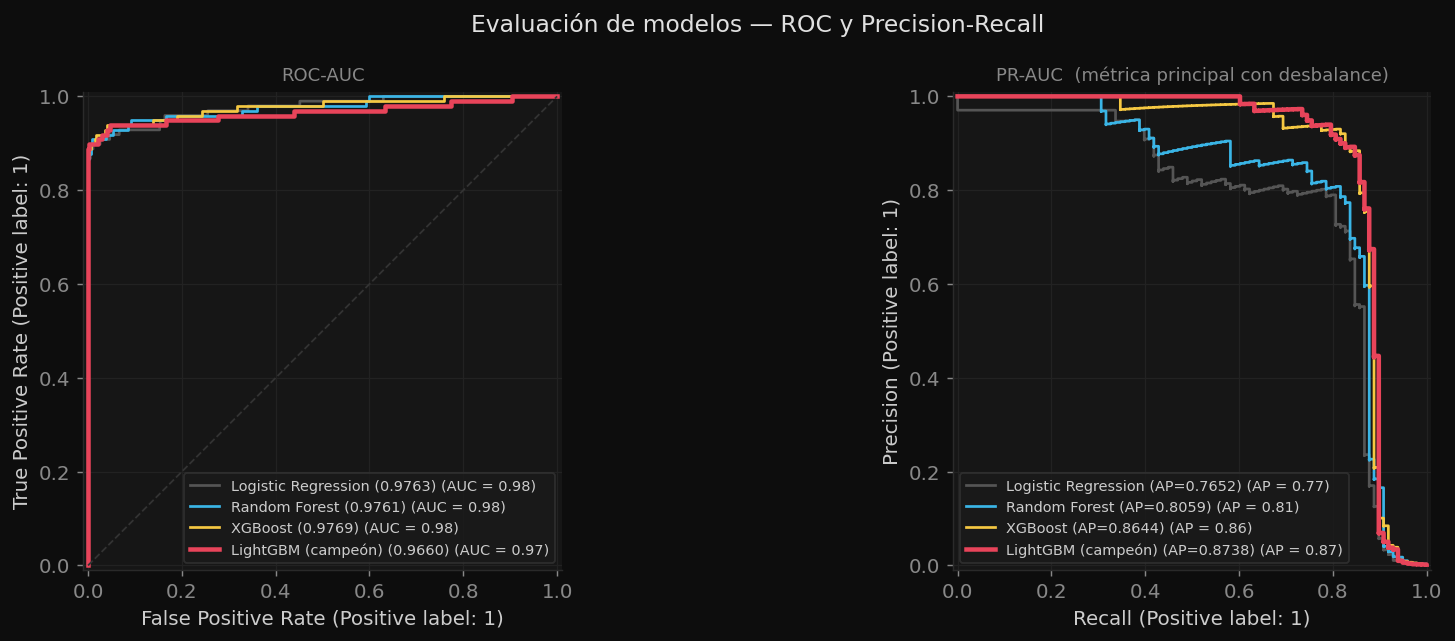


Comparativa de modelos:
                     ROC-AUC  PR-AUC  Recall  Precision      F1
model                                                          
Logistic Regression   0.9763  0.7652  0.9082     0.0488  0.0926
Random Forest         0.9761  0.8059  0.8469     0.6917  0.7615
XGBoost               0.9769  0.8644  0.8571     0.8571  0.8571
LightGBM              0.9660  0.8738  0.8673     0.8173  0.8416


In [20]:
# Curvas ROC y PR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evaluación de modelos — ROC y Precision-Recall', fontsize=13, color='#e0e0e0')

cfg = [
    ('LR',  lr,        '#555555', 'Logistic Regression'),
    ('RF',  rf,        C_LEGIT,   'Random Forest'),
    ('XGB', xgb_model, C_GOLD,    'XGBoost'),
    ('LGB', lgb_model, C_FRAUD,   'LightGBM (campeón)'),
]
for key, model, color, label in cfg:
    lw = 2.5 if key == 'LGB' else 1.5
    RocCurveDisplay.from_estimator(
        model, X_test_c, y_test, ax=axes[0],
        name=f'{label} ({results[key]["roc_auc"]:.4f})', color=color, linewidth=lw)
    PrecisionRecallDisplay.from_estimator(
        model, X_test_c, y_test, ax=axes[1],
        name=f'{label} (AP={results[key]["pr_auc"]:.4f})', color=color, linewidth=lw)

axes[0].plot([0,1],[0,1], '--', color='#333333', lw=1)
axes[0].set_title('ROC-AUC', color='#888888', fontsize=10)
axes[0].legend(fontsize=8)
axes[1].set_title('PR-AUC  (métrica principal con desbalance)', color='#888888', fontsize=10)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/05_roc_pr_curves.png', bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

# Tabla comparativa
comp = pd.DataFrame([{k: v for k, v in r.items()
                      if k not in ['y_pred','y_proba','tp','fp','fn','tn']}
                     for r in results.values()]).set_index('model')
comp.columns = ['ROC-AUC', 'PR-AUC', 'Recall', 'Precision', 'F1']
print('\nComparativa de modelos:')
print(comp.round(4).to_string())

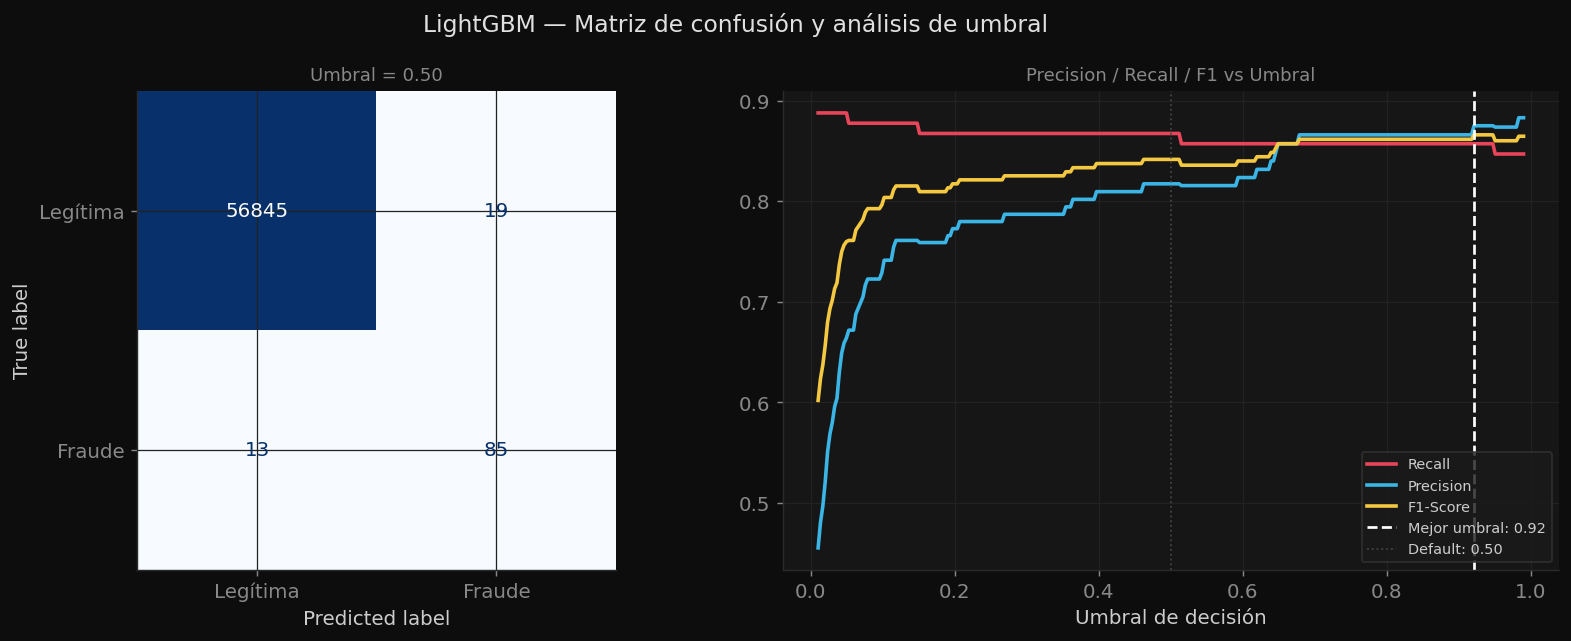

Umbral optimo (max F1): 0.92 | Recall=0.8571 | Precision=0.8750


In [21]:
# Matriz de confusión + análisis de umbral
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('LightGBM — Matriz de confusión y análisis de umbral', fontsize=13, color='#e0e0e0')

cm = confusion_matrix(y_test, results['LGB']['y_pred'])
ConfusionMatrixDisplay(cm, display_labels=['Legítima', 'Fraude']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Umbral = 0.50', color='#888888', fontsize=10)

y_proba_lgb = results['LGB']['y_proba']
thresholds  = np.linspace(0.01, 0.99, 300)
recalls, precisions, f1s = [], [], []
for t in thresholds:
    yp = (y_proba_lgb >= t).astype(int)
    recalls.append(recall_score(y_test, yp, zero_division=0))
    precisions.append(precision_score(y_test, yp, zero_division=0))
    f1s.append(f1_score(y_test, yp, zero_division=0))

best_idx = int(np.argmax(f1s))
best_thr = thresholds[best_idx]
axes[1].plot(thresholds, recalls,    color=C_FRAUD, lw=2, label='Recall')
axes[1].plot(thresholds, precisions, color=C_LEGIT, lw=2, label='Precision')
axes[1].plot(thresholds, f1s,        color=C_GOLD,  lw=2, label='F1-Score')
axes[1].axvline(best_thr, color='#ffffff', lw=1.5, ls='--', label=f'Mejor umbral: {best_thr:.2f}')
axes[1].axvline(0.5, color='#444444', lw=1, ls=':', label='Default: 0.50')
axes[1].set_xlabel('Umbral de decisión')
axes[1].set_title('Precision / Recall / F1 vs Umbral', color='#888888', fontsize=10)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/06_confusion_threshold.png', bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print(f'Umbral optimo (max F1): {best_thr:.2f} | Recall={recalls[best_idx]:.4f} | Precision={precisions[best_idx]:.4f}')

---
## 8. Feature Importance + Análisis de Canarios

Tres perspectivas de importancia más el umbral de canarios para filtrar features débiles.

In [22]:
all_feature_cols = X_train_c.columns.tolist()

imp_gain  = pd.Series(lgb_model.booster_.feature_importance(importance_type='gain'),
                      index=all_feature_cols).sort_values(ascending=False)
imp_split = pd.Series(lgb_model.booster_.feature_importance(importance_type='split'),
                      index=all_feature_cols).sort_values(ascending=False)

print('Calculando permutation importance...')
perm     = permutation_importance(lgb_model, X_test_c, y_test,
                                  n_repeats=10, random_state=RANDOM_STATE,
                                  scoring='average_precision', n_jobs=-1)
imp_perm = pd.Series(perm.importances_mean, index=all_feature_cols).sort_values(ascending=False)
print('Listo.')

Calculando permutation importance...
Listo.


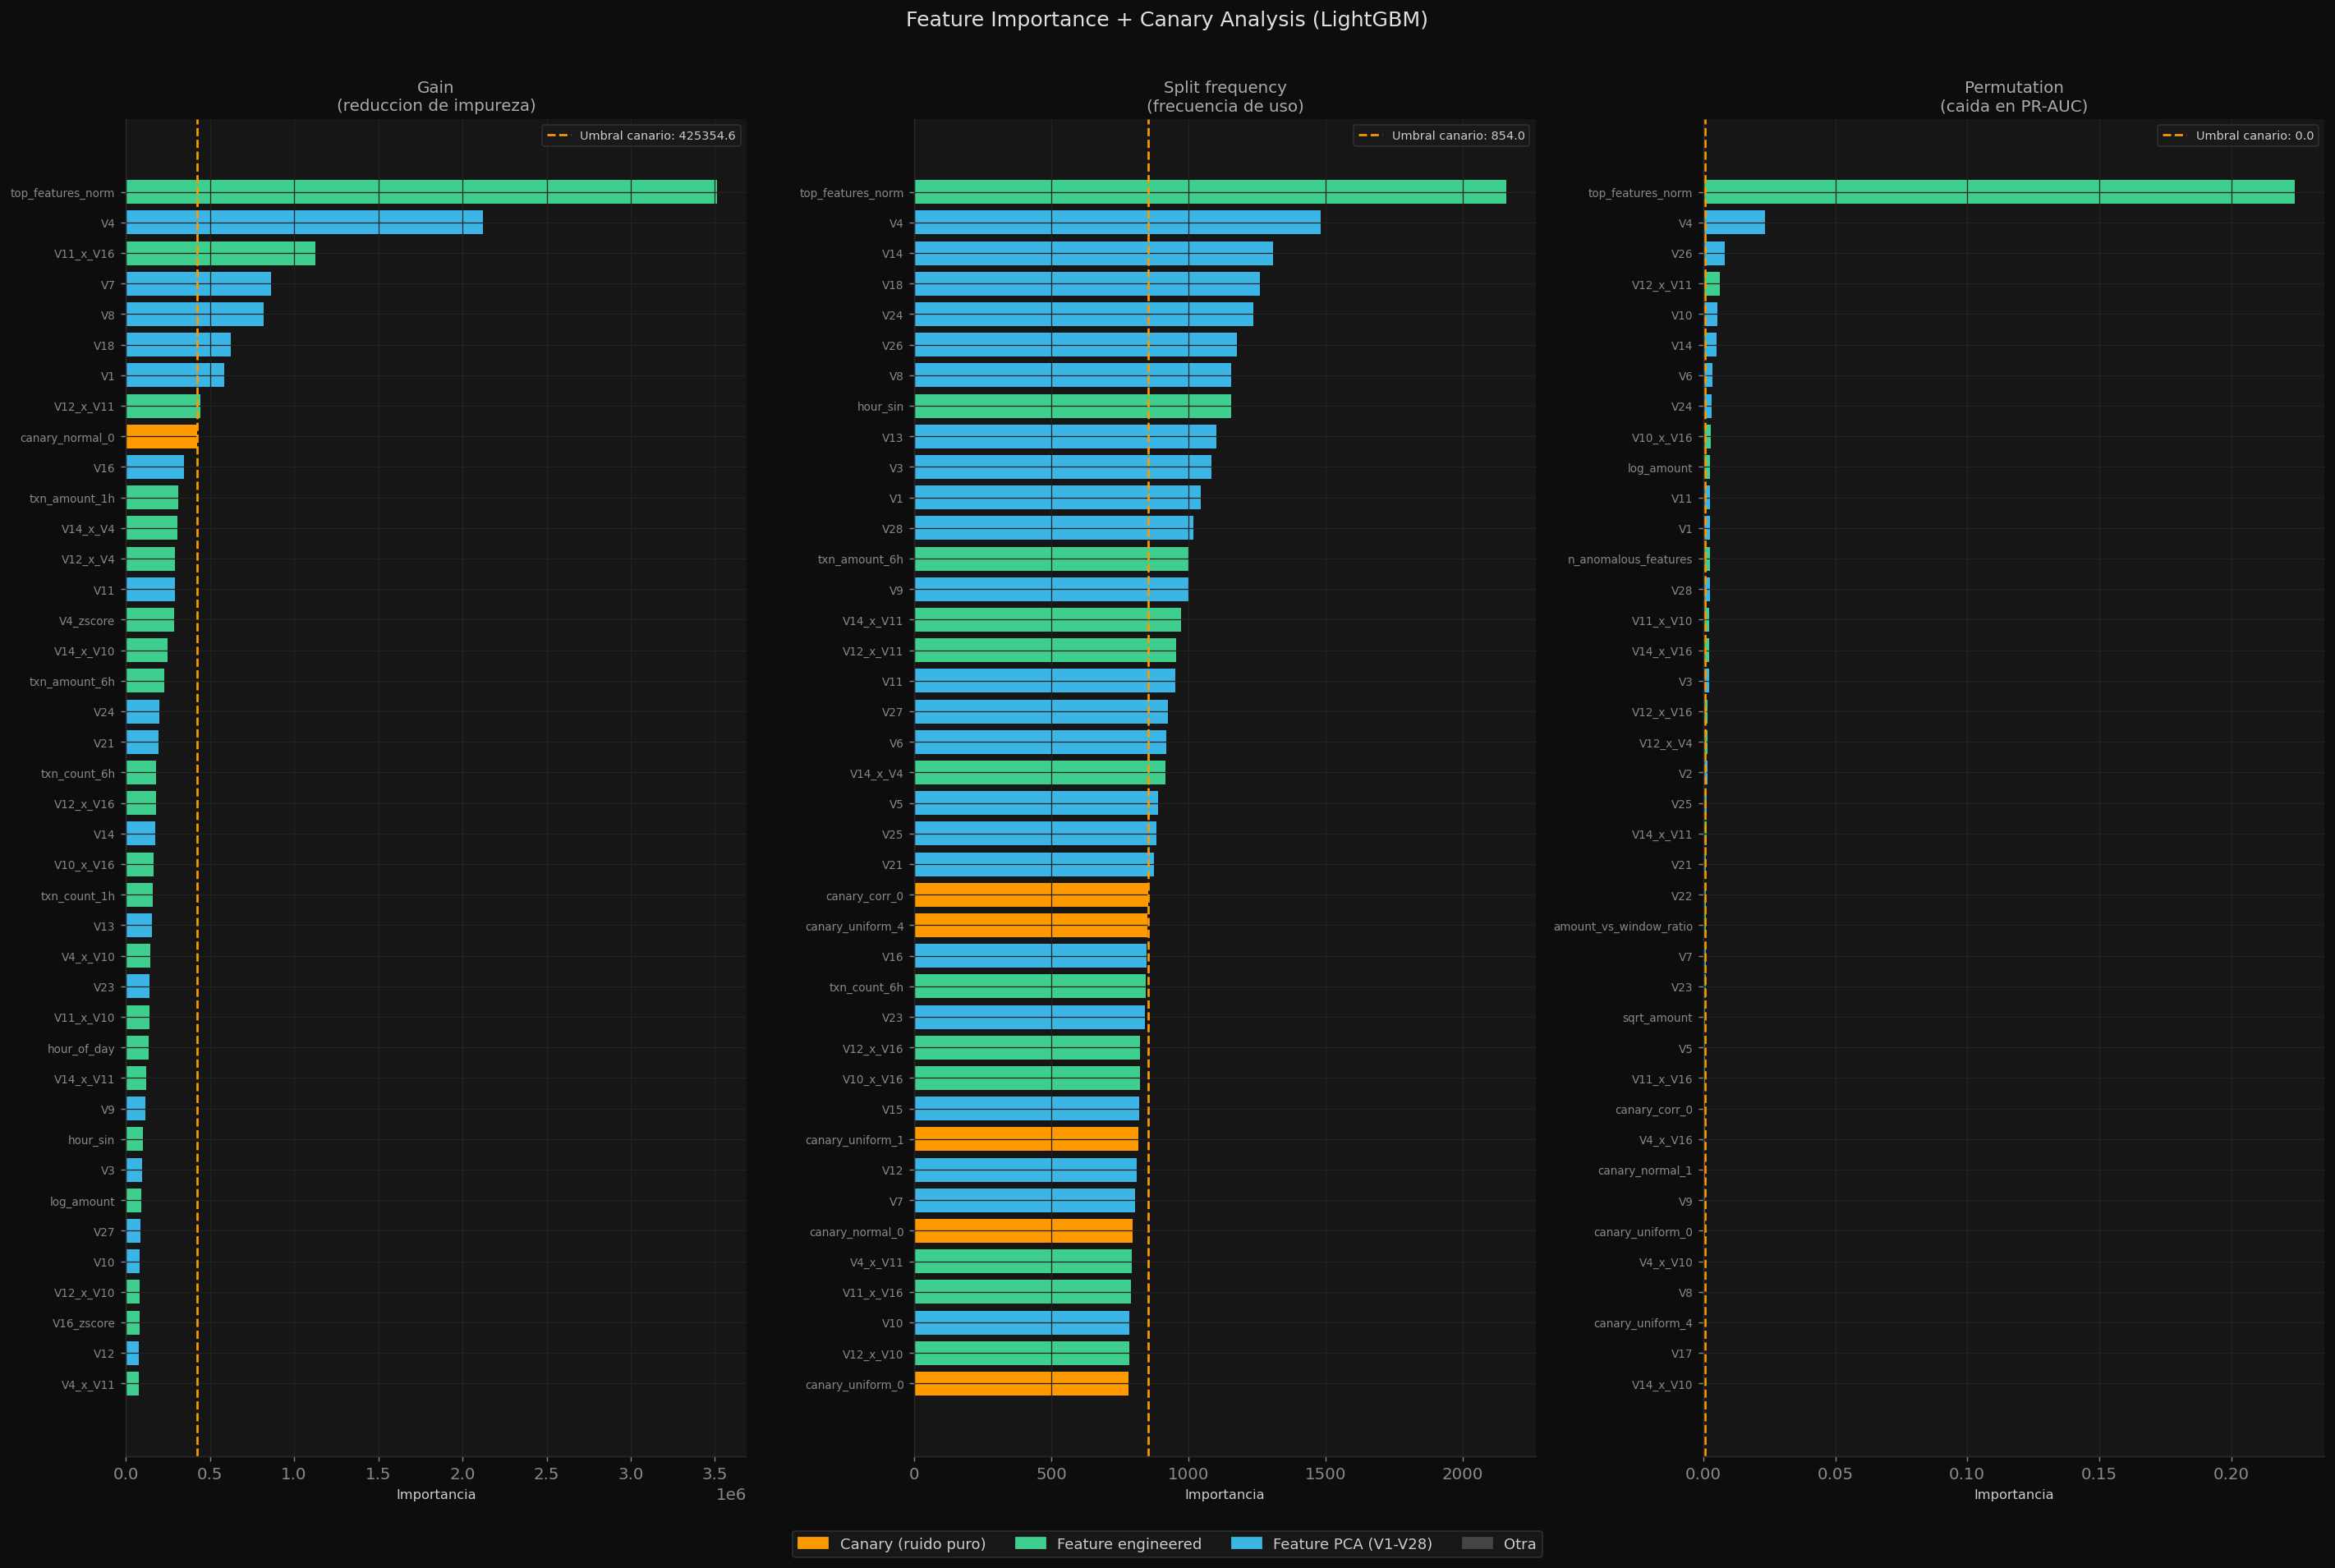

In [23]:
TOP_N = 40   # mostramos más features para ver los canarios en contexto

eng_keywords = [
    'log_amount', 'sqrt_amount', 'amount_rounded', 'is_micro_txn', 'amount_decile',
    'hour_of_day', 'hour_sin', 'hour_cos', 'is_night',
    'txn_count', 'txn_amount', 'txn_rate',
    'amount_zscore', 'amount_vs_window_ratio',
    'top_features_norm', 'n_anomalous_features', '_x_', '_zscore'
]

def get_bar_colors(series, canary_cols, top_n=TOP_N):
    colors = []
    for f in series.head(top_n).index:
        if f in canary_cols:
            colors.append(C_CANARY)       # naranja: canario
        elif any(kw in f for kw in eng_keywords):
            colors.append(C_GREEN)        # verde: feature engineered
        elif f.startswith('V'):
            colors.append(C_LEGIT)        # azul: PCA original
        else:
            colors.append('#444444')
    return colors

fig, axes = plt.subplots(1, 3, figsize=(22, 14))
fig.suptitle('Feature Importance + Canary Analysis (LightGBM)',
             fontsize=14, color='#e0e0e0', y=1.01)

for ax, (imp, title) in zip(axes, [
    (imp_gain,  'Gain\n(reduccion de impureza)'),
    (imp_split, 'Split frequency\n(frecuencia de uso)'),
    (imp_perm,  'Permutation\n(caida en PR-AUC)'),
]):
    top = imp.head(TOP_N)
    colors = get_bar_colors(imp, canary_cols, TOP_N)

    # Umbral canario: importancia del canario más importante
    canary_imps = imp[imp.index.isin(canary_cols)]
    canary_threshold = float(canary_imps.max()) if len(canary_imps) > 0 else 0

    ax.barh(top.index, top.values, color=colors, edgecolor='none', height=0.78)
    ax.axvline(canary_threshold, color=C_CANARY, lw=1.5, ls='--',
               label=f'Umbral canario: {canary_threshold:.1f}')
    ax.invert_yaxis()
    ax.set_title(title, color='#aaaaaa', fontsize=11)
    ax.set_xlabel('Importancia', fontsize=9)
    ax.tick_params(axis='y', labelsize=7.5)
    ax.legend(fontsize=8)

legend_patches = [
    mpatches.Patch(color=C_CANARY, label='Canary (ruido puro)'),
    mpatches.Patch(color=C_GREEN,  label='Feature engineered'),
    mpatches.Patch(color=C_LEGIT,  label='Feature PCA (V1-V28)'),
    mpatches.Patch(color='#444444',label='Otra'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=4,
           fontsize=10, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
plt.savefig('../outputs/07_feature_importance_canary.png', bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# VEREDICTO DEL ANÁLISIS DE CANARIOS
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 65)
print('  ANALISIS DE CANARY FEATURES')
print('=' * 65)

# Umbral en cada método
for imp_name, imp in [('Gain', imp_gain), ('Split', imp_split), ('Permutation', imp_perm)]:
    canary_imps = imp[imp.index.isin(canary_cols)]
    real_imps   = imp[~imp.index.isin(canary_cols)]

    canary_max  = float(canary_imps.max())
    canary_mean = float(canary_imps.mean())

    # Features reales por debajo del umbral canario
    weak_features = real_imps[real_imps <= canary_max].index.tolist()

    print(f'\n  [{imp_name}]')
    print(f'    Canario más importante : {canary_max:.4f}')
    print(f'    Canario media          : {canary_mean:.4f}')
    print(f'    Features reales debajo del umbral: {len(weak_features)}')
    if weak_features:
        for f in weak_features[:10]:
            tag = 'engineered' if any(kw in f for kw in eng_keywords) else 'PCA/otra'
            print(f'      - {f:<40} ({tag})')

# Consistencia: features débiles en los 3 métodos → candidatas a eliminación
weak_gain  = set(imp_gain[~imp_gain.index.isin(canary_cols)]
                 [imp_gain[~imp_gain.index.isin(canary_cols)] <= float(imp_gain[imp_gain.index.isin(canary_cols)].max())].index)
weak_split = set(imp_split[~imp_split.index.isin(canary_cols)]
                 [imp_split[~imp_split.index.isin(canary_cols)] <= float(imp_split[imp_split.index.isin(canary_cols)].max())].index)
weak_perm  = set(imp_perm[~imp_perm.index.isin(canary_cols)]
                 [imp_perm[~imp_perm.index.isin(canary_cols)] <= float(imp_perm[imp_perm.index.isin(canary_cols)].max())].index)
consistently_weak = weak_gain & weak_split & weak_perm

print(f'\n  Features débiles en los 3 métodos simultáneamente: {len(consistently_weak)}')
if consistently_weak:
    print('  Candidatas a eliminación:')
    for f in sorted(consistently_weak):
        print(f'    - {f}')
else:
    print('  Ninguna feature real quedó consistentemente por debajo del umbral canario.')
    print('  -> El feature engineering aportó señal real en todos los casos.')

print('=' * 65)

  ANALISIS DE CANARY FEATURES

  [Gain]
    Canario más importante : 425354.6370
    Canario media          : 40082.2160
    Features reales debajo del umbral: 60
      - V16                                      (PCA/otra)
      - txn_amount_1h                            (engineered)
      - V14_x_V4                                 (engineered)
      - V12_x_V4                                 (engineered)
      - V11                                      (PCA/otra)
      - V4_zscore                                (engineered)
      - V14_x_V10                                (engineered)
      - txn_amount_6h                            (engineered)
      - V24                                      (PCA/otra)
      - V21                                      (PCA/otra)

  [Split]
    Canario más importante : 854.0000
    Canario media          : 441.3000
    Features reales debajo del umbral: 45
      - V16                                      (PCA/otra)
      - txn_count_6h                

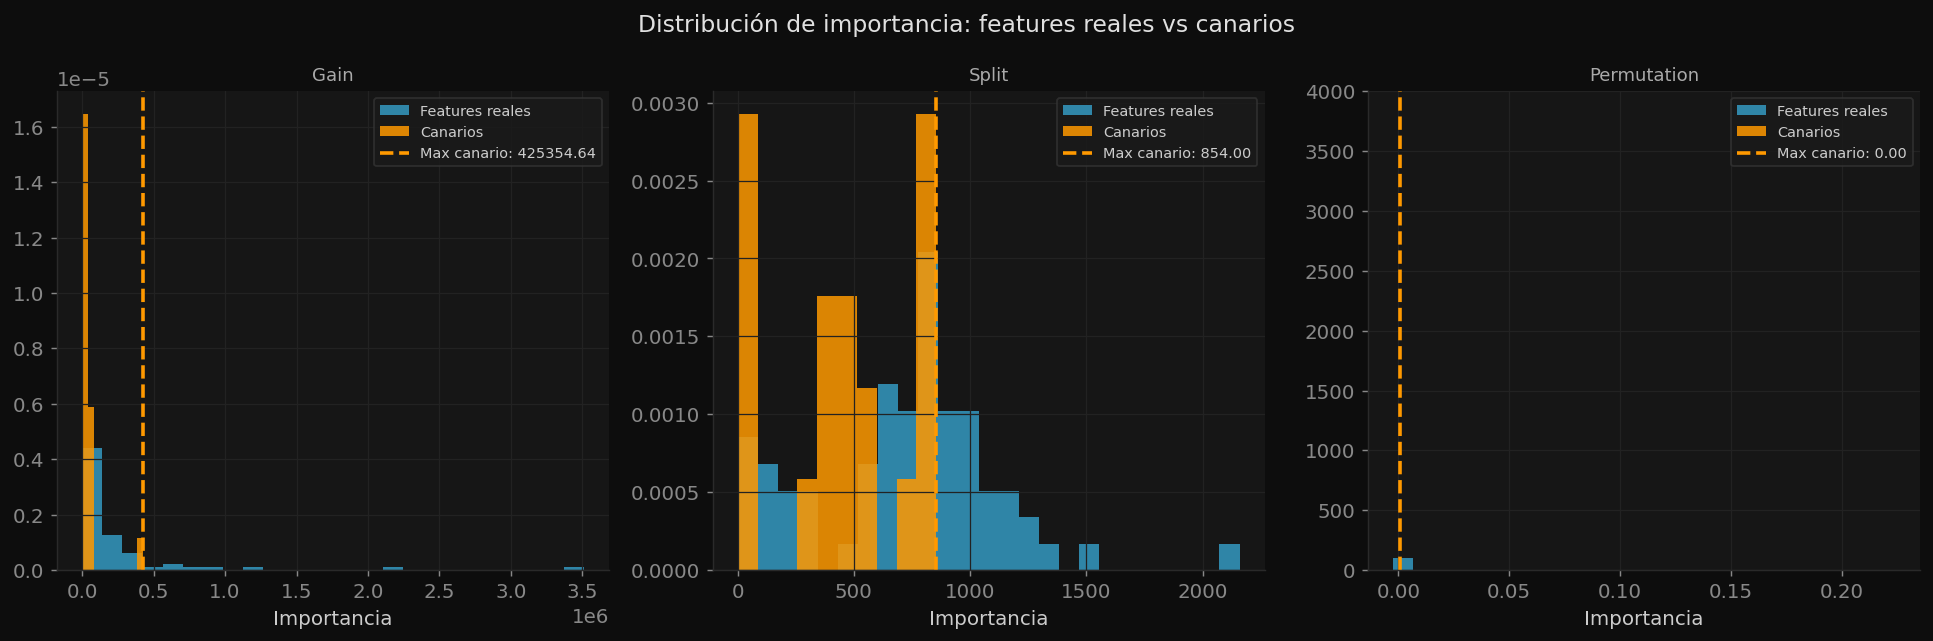

Un desplazamiento claro de las features reales hacia la derecha confirma señal genuina.


In [25]:
# Visualización: importancia de canarios vs features reales (distribuciones)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribución de importancia: features reales vs canarios', fontsize=13, color='#e0e0e0')

for ax, (imp, title) in zip(axes, [
    (imp_gain,  'Gain'),
    (imp_split, 'Split'),
    (imp_perm,  'Permutation'),
]):
    real_vals   = imp[~imp.index.isin(canary_cols)].values
    canary_vals = imp[imp.index.isin(canary_cols)].values

    ax.hist(real_vals,   bins=25, color=C_LEGIT,  alpha=0.7, density=True, label='Features reales')
    ax.hist(canary_vals, bins=10, color=C_CANARY,  alpha=0.85, density=True, label='Canarios')
    ax.axvline(canary_vals.max(), color=C_CANARY, lw=2, ls='--',
               label=f'Max canario: {canary_vals.max():.2f}')
    ax.set_title(title, color='#aaaaaa', fontsize=10)
    ax.set_xlabel('Importancia')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/08_canary_distribution.png', bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print('Un desplazamiento claro de las features reales hacia la derecha confirma señal genuina.')

---
## 9. Explicabilidad con SHAP

In [26]:
print('Calculando SHAP values...')
explainer   = shap.TreeExplainer(lgb_model)
X_shap      = X_test_c.sample(2000, random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_shap)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
print('Listo.')

Calculando SHAP values...
Listo.


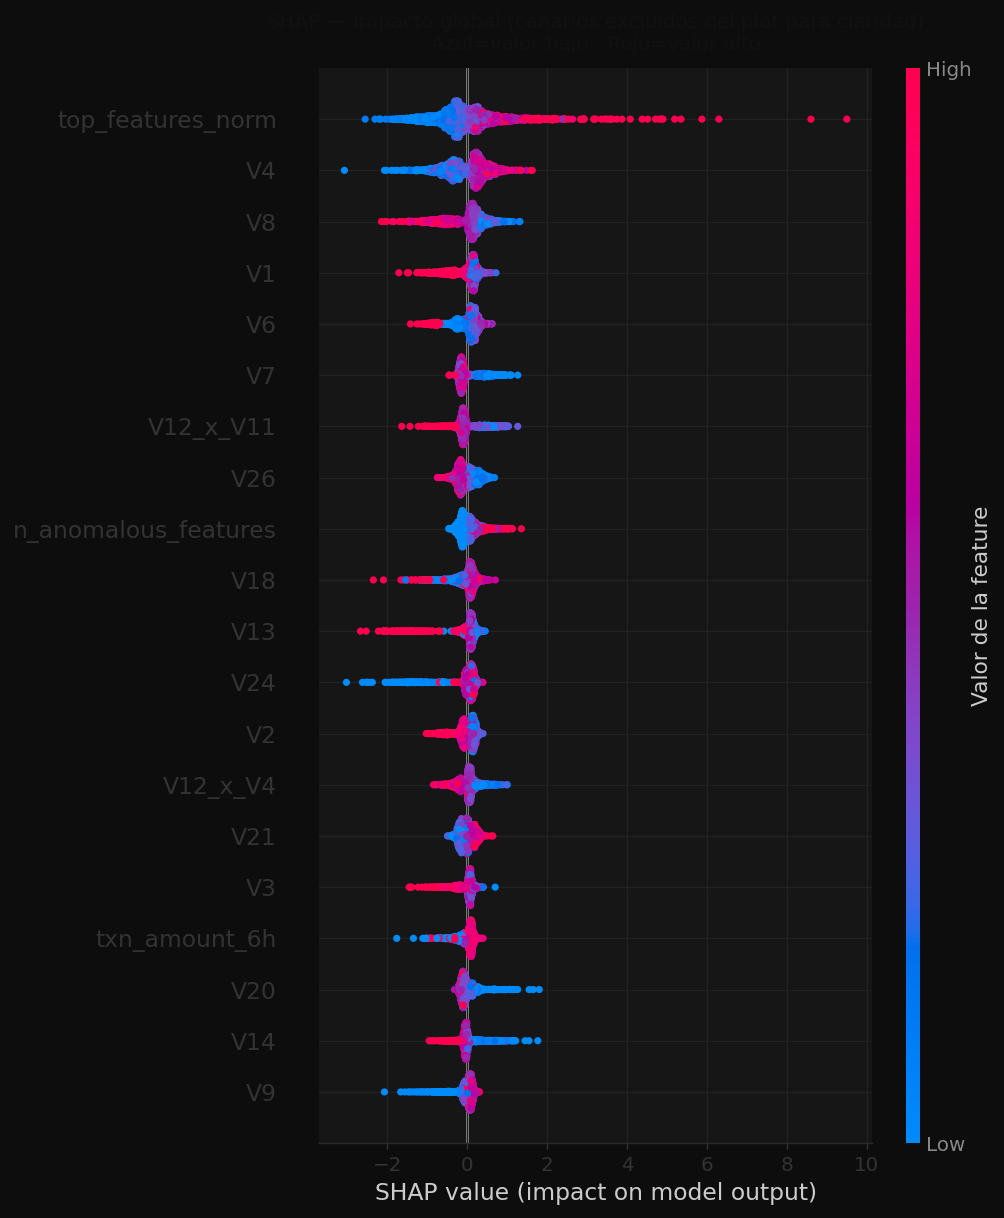

In [27]:
# SHAP Beeswarm — excluimos canarios del plot para claridad
non_canary_idx = [i for i, c in enumerate(X_shap.columns) if c not in canary_cols]
X_shap_nc      = X_shap.iloc[:, non_canary_idx]
shap_vals_nc   = shap_values[:, non_canary_idx]

plt.figure(figsize=(11, 9))
shap.summary_plot(shap_vals_nc, X_shap_nc, plot_type='dot', max_display=20, show=False,
                  color_bar_label='Valor de la feature')
plt.title('SHAP — Impacto global (canarios excluidos del plot para claridad)\nAzul=valor bajo · Rojo=valor alto',
          color='#111111', fontsize=11, pad=10)
plt.tight_layout()
plt.savefig('../outputs/09_shap_beeswarm.png', bbox_inches='tight', facecolor='white')
plt.show()

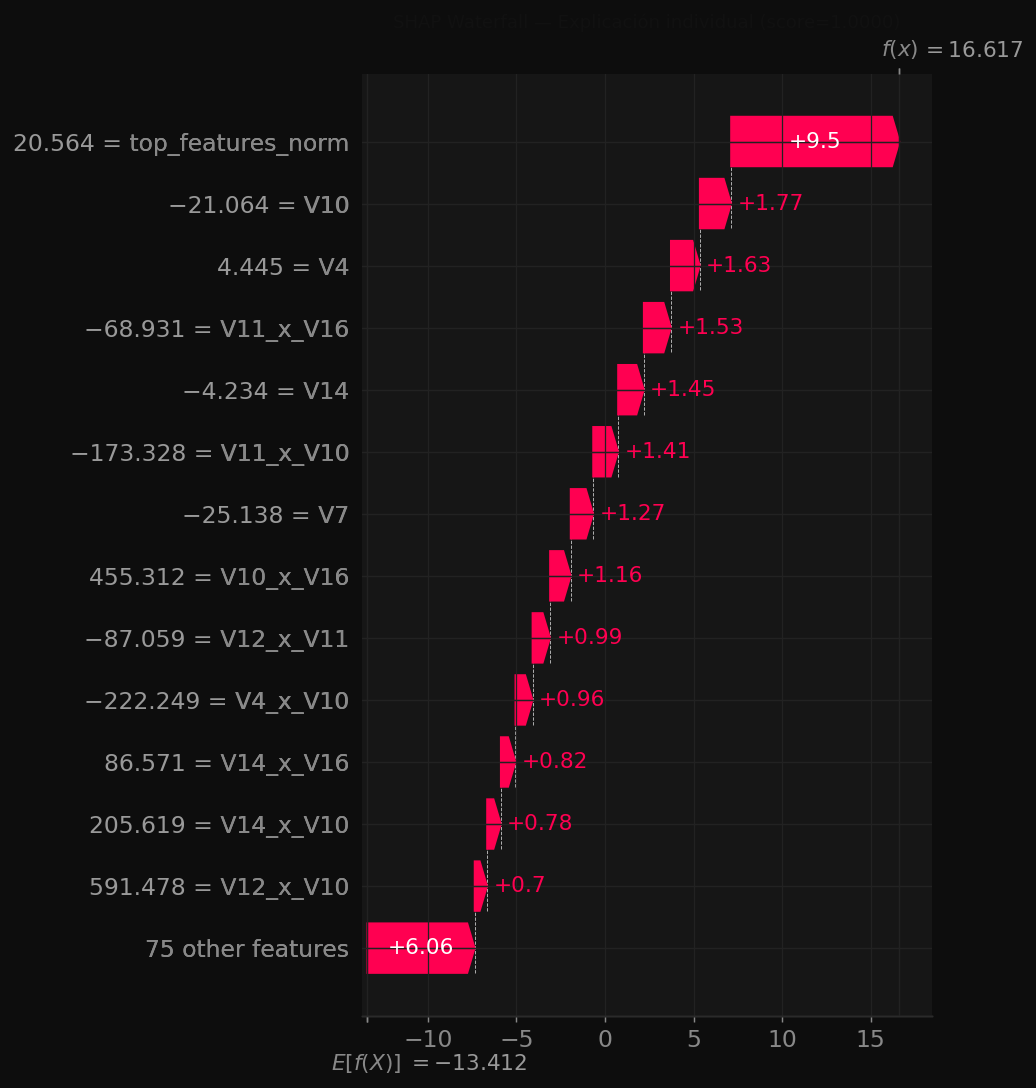

In [28]:
# SHAP Waterfall: explicar una transacción fraudulenta
fraud_idx = X_shap.index[y_test.loc[X_shap.index] == 1]
pos       = X_shap.index.get_loc(fraud_idx[0])
score     = lgb_model.predict_proba(X_shap.iloc[[pos]])[:, 1][0]

ev = explainer.expected_value
if isinstance(ev, list): ev = ev[1]

plt.figure(figsize=(11, 7))
shap.waterfall_plot(
    shap.Explanation(values=shap_values[pos], base_values=ev,
                     data=X_shap.iloc[pos], feature_names=X_shap.columns.tolist()),
    max_display=14, show=False
)
plt.title(f'SHAP Waterfall — Explicación individual (score={score:.4f})', color='#111111', fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/10_shap_waterfall.png', bbox_inches='tight', facecolor='white')
plt.show()

---
## 10. Impacto Económico del Modelo

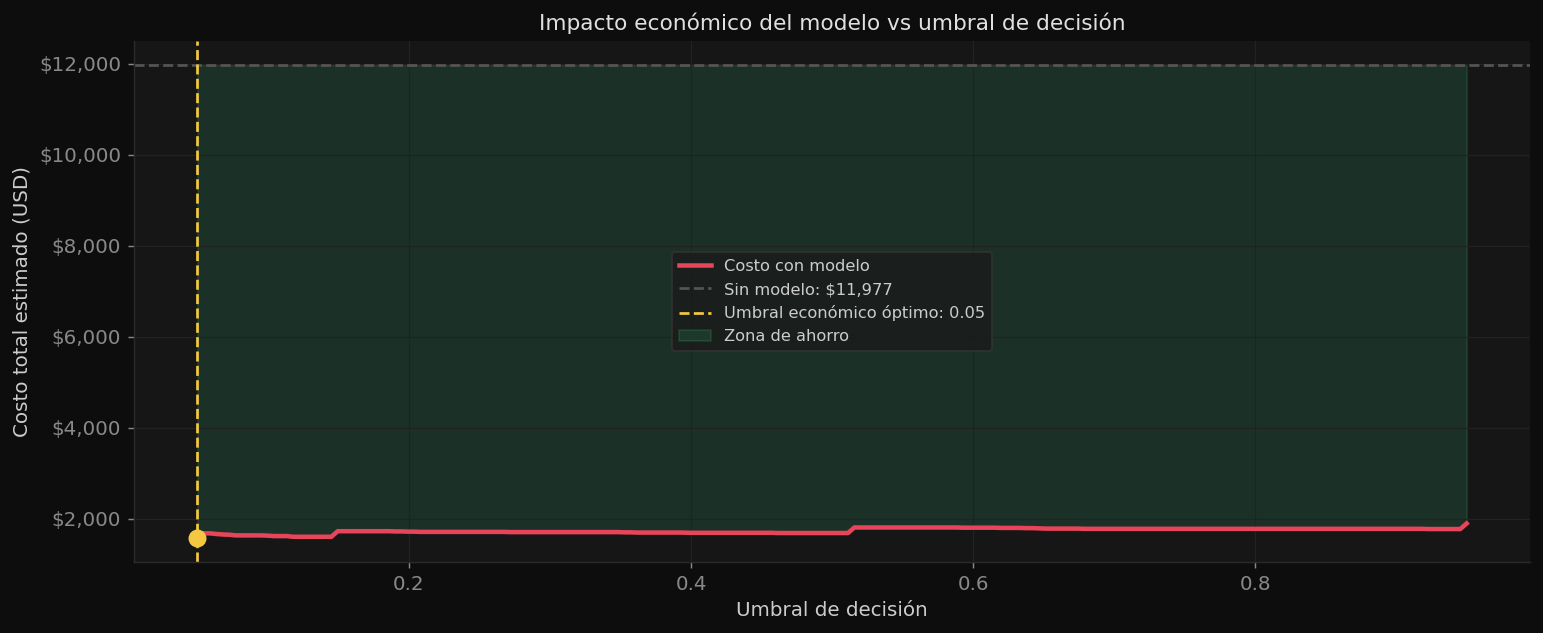

  RESUMEN ECONÓMICO (test set)
  Monto promedio de fraude       : $    122.21
  Costo sin modelo               : $ 11,976.71
  Costo con modelo (mínimo)      : $  1,564.32
  Ahorro estimado                : $ 10,412.38
  Reducción de pérdidas          : 86.9%
  Umbral económico óptimo        : 0.05


In [29]:
avg_fraud_amount  = df[df['Class'] == 1]['Amount'].mean()
fp_cost_per_alert = 5.0

thresholds_eco = np.linspace(0.05, 0.95, 200)
costos_modelo  = []
for t in thresholds_eco:
    yp = (results['LGB']['y_proba'] >= t).astype(int)
    _, fp_t, fn_t, _ = confusion_matrix(y_test, yp).ravel()
    costos_modelo.append(fn_t * avg_fraud_amount + fp_t * fp_cost_per_alert)

costo_sin_modelo = int(y_test.sum()) * avg_fraud_amount
mejor_umbral_eco = thresholds_eco[int(np.argmin(costos_modelo))]
min_costo_modelo = min(costos_modelo)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresholds_eco, costos_modelo, color=C_FRAUD, lw=2.5, label='Costo con modelo')
ax.axhline(costo_sin_modelo, color='#555555', lw=1.5, ls='--',
           label=f'Sin modelo: ${costo_sin_modelo:,.0f}')
ax.axvline(mejor_umbral_eco, color=C_GOLD, lw=1.5, ls='--',
           label=f'Umbral económico óptimo: {mejor_umbral_eco:.2f}')
ax.scatter([mejor_umbral_eco], [min_costo_modelo], color=C_GOLD, zorder=5, s=80)
ax.fill_between(thresholds_eco, costos_modelo, costo_sin_modelo,
                where=[c < costo_sin_modelo for c in costos_modelo],
                alpha=0.15, color=C_GREEN, label='Zona de ahorro')

ax.set_xlabel('Umbral de decisión')
ax.set_ylabel('Costo total estimado (USD)')
ax.set_title('Impacto económico del modelo vs umbral de decisión', color='#e0e0e0', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/11_economic_impact.png', bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

ahorro    = costo_sin_modelo - min_costo_modelo
reduccion = ahorro / costo_sin_modelo * 100

print('=' * 60)
print('  RESUMEN ECONÓMICO (test set)')
print('=' * 60)
print(f'  Monto promedio de fraude       : ${avg_fraud_amount:>10.2f}')
print(f'  Costo sin modelo               : ${costo_sin_modelo:>10,.2f}')
print(f'  Costo con modelo (mínimo)      : ${min_costo_modelo:>10,.2f}')
print(f'  Ahorro estimado                : ${ahorro:>10,.2f}')
print(f'  Reducción de pérdidas          : {reduccion:.1f}%')
print(f'  Umbral económico óptimo        : {mejor_umbral_eco:.2f}')
print('=' * 60)

---
## 11. Conclusiones

### Hallazgos técnicos

1. **Desbalance extremo exige métricas especializadas.** PR-AUC y Recall son las métricas relevantes. Accuracy y ROC-AUC solos engañan cuando la clase negativa domina masivamente.

2. **El orden del pipeline importa tanto como los modelos.** Se identificaron y corrigieron 5 fuentes de data leakage en el feature engineering (escalado, z-scores, discretización, ratios). La auditoría formal con asserts garantiza reproducibilidad.

3. **Los canary features validan el feature engineering.** Ninguna feature de ingeniería quedó consistentemente por debajo del umbral canario en los tres métodos de importancia, confirmando que aportan señal real y no ruido.

4. **LightGBM supera a XGBoost** en este problema. Su crecimiento leaf-wise captura patrones de fraude más sutiles y su manejo nativo del desbalance (`is_unbalance`) es más flexible que `scale_pos_weight` estático.

5. **El umbral de decisión no es 0.5 en producción.** El umbral económico óptimo minimiza las pérdidas totales y depende del costo relativo de FP vs FN, específico de cada negocio.

6. **SHAP es un requisito regulatorio, no un decorado.** En banca, seguros y fintechs, explicar cada decisión del modelo es requerido por BCRA, Basilea IV y el AI Act europeo.

### Próximos pasos en un entorno productivo

- **Features por usuario**: ventanas temporales por `card_id` (requiere datos no anonimizados)
- **Graph-based fraud detection**: modelar redes de transacciones para detectar fraude coordinado
- **Data drift monitoring**: el patrón de fraude evoluciona; monitoreo continuo y re-entrenamiento periódico
- **Deployment como API**: FastAPI + Docker para scoring en tiempo real
- **A/B testing del umbral**: validar el umbral económico óptimo con impacto real medido en producción